## Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
df=pd.read_csv('Dataset.csv', sep=';')

In [3]:
# Info dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  object 
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  object 
 7   Fertilizer       19689 non-null  object 
 8   Pesticide        19689 non-null  object 
 9   Yield            19689 non-null  object 
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 2.0+ MB
None


In [4]:
print("\nMemperbaiki konversi kolom numerik...")
NUM_COLS = ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Production']

def clean_numeric(value):
    if pd.isna(value): return np.nan
    s = str(value).strip()
    # Jika ada lebih dari satu titik, itu pasti pemisah ribuan (e.g. 1.269.050)
    if s.count('.') > 1:
        s = s.replace('.', '')
    # Jika ada koma, ganti jadi titik untuk standar float Python
    s = s.replace(',', '.')
    return s

for col in NUM_COLS:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Isi kembali nilai yang gagal parsing dengan median agar tidak ada NaN
for col in NUM_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Konversi selesai dengan penanganan pemisah ribuan yang lebih akurat.")
display(df[NUM_COLS].head())


Memperbaiki konversi kolom numerik...
Konversi selesai dengan penanganan pemisah ribuan yang lebih akurat.


,Area,Annual_Rainfall,Fertilizer,Pesticide,Yield,Production
0,73814.0,2051.4,7024878.38,22882.34,0.796,56708
1,6637.0,2051.4,631643.29,2057.47,0.710,4685
2,796.0,2051.4,75755.32,246.76,0.238,22
3,19656.0,2051.4,1870661.52,6093.36,5238052.000,126905000
4,1739.0,2051.4,165500.63,539.09,0.421,794


In [5]:
print(display(df.head()))

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238052.000,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


None


In [6]:
print("--- Deskripsi Statistik ---")
display(df.describe())

--- Deskripsi Statistik ---


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.801805e+05,1.643594e+07,5.995636e+04,4.087439e+07,2.747498e+05,6.394414e+04,23.831279,33.947314,14.723357
std,6.498099,7.329891e+05,2.630568e+08,3.275310e+05,3.262109e+08,5.480682e+06,8.043395e+05,5.847672,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,3.013000e+02,5.417000e+01,9.000000e-02,0.000000e+00,-5.115000,7.701000,-19.359000
25%,2004.000000,1.393000e+03,1.393000e+03,9.407000e+02,1.914744e+05,3.567000e+02,6.000000e-01,23.545000,32.483000,13.535000
50%,2010.000000,9.325000e+03,1.380400e+04,1.257200e+03,1.268965e+06,2.445700e+03,1.030000e+00,25.675000,35.826000,15.890000
75%,2015.000000,7.520600e+04,1.227180e+05,1.734300e+03,1.062804e+07,2.068115e+04,2.389000e+00,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,4.083105e+06,9.971196e+09,3.450145e+08,1.693506e+07,28.652000,40.632000,24.972000


## Data Preprocessing

In [7]:
print("--- Pemeriksaan Nilai Hilang ---")
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)
missing_df = pd.DataFrame({'Missing Count': missing_values,
                           'Missing Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if missing_df.empty:
    print("Tidak ada nilai yang hilang dalam dataset.")
else:
    display(missing_df)

--- Pemeriksaan Nilai Hilang ---
Tidak ada nilai yang hilang dalam dataset.


In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("--- Deteksi Outlier Menggunakan Metode IQR ---")
outlier_counts = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghitung jumlah outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

print("Jumlah Outlier per Kolom (Menggunakan Metode IQR):")
for col, count in outlier_counts.items():
    print(f"{col}: {count} outlier")

--- Deteksi Outlier Menggunakan Metode IQR ---
Jumlah Outlier per Kolom (Menggunakan Metode IQR):
Crop_Year: 0 outlier
Area: 3078 outlier
Production: 3373 outlier
Annual_Rainfall: 1902 outlier
Fertilizer: 3117 outlier
Pesticide: 3086 outlier
Yield: 3065 outlier
Avg_Temperature: 1801 outlier
Max_Temperature: 857 outlier
Min_Temperature: 1527 outlier


In [9]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Terapkan capping dan flooring
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

print("Menerapkan capping/flooring untuk mengatasi outlier...")

# Definisikan NUM_COLS_CHECK. Menggunakan numerical_cols yang sudah ada.
NUM_COLS_CHECK = numerical_cols

# Kolom-kolom yang akan diatasi outliernya
for col in NUM_COLS_CHECK:
    if col in df.columns:
        df = cap_outliers_iqr(df.copy(), col)
        print(f"  Outlier di kolom '{col}' telah ditangani.")

print("Penanganan outlier selesai.")

Menerapkan capping/flooring untuk mengatasi outlier...
  Outlier di kolom 'Crop_Year' telah ditangani.
  Outlier di kolom 'Area' telah ditangani.
  Outlier di kolom 'Production' telah ditangani.
  Outlier di kolom 'Annual_Rainfall' telah ditangani.
  Outlier di kolom 'Fertilizer' telah ditangani.
  Outlier di kolom 'Pesticide' telah ditangani.
  Outlier di kolom 'Yield' telah ditangani.
  Outlier di kolom 'Avg_Temperature' telah ditangani.
  Outlier di kolom 'Max_Temperature' telah ditangani.
  Outlier di kolom 'Min_Temperature' telah ditangani.
Penanganan outlier selesai.


Membuat boxplot untuk setiap kolom numerik...


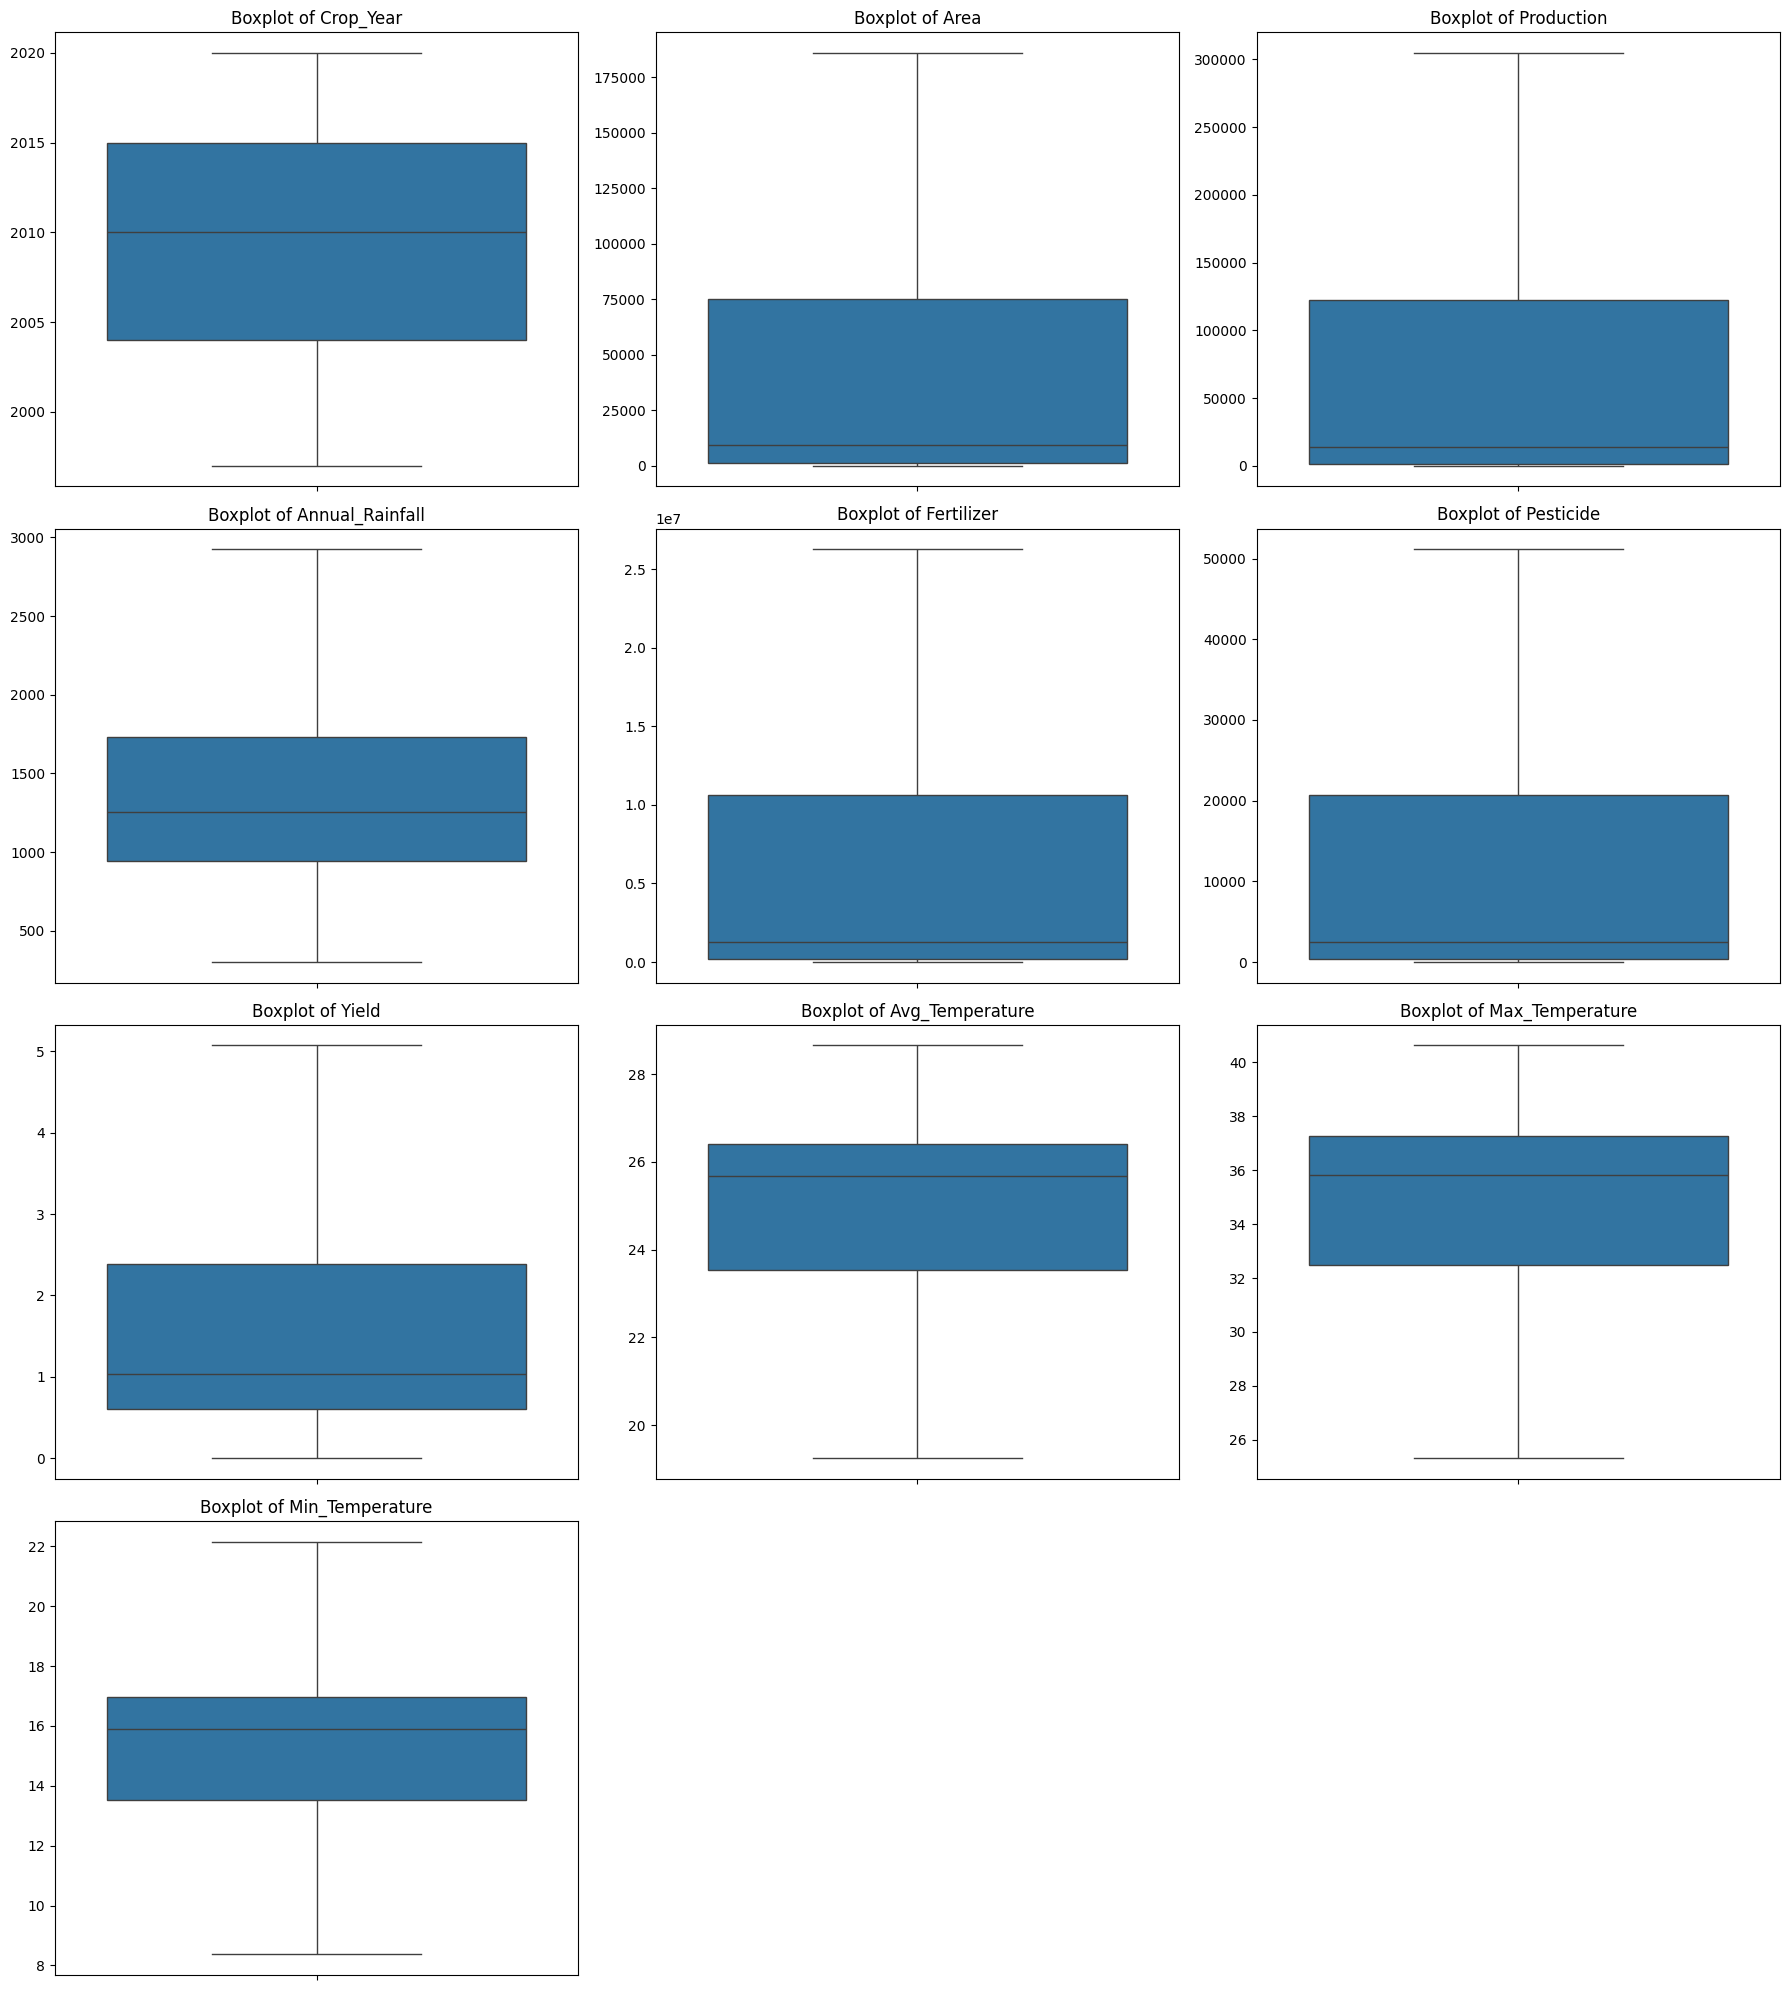

Boxplot selesai dibuat.


In [10]:

# Memastikan `numerical_cols` terdefinisi
if 'numerical_cols' not in locals():
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Membuat boxplot untuk setiap kolom numerik...")

# Jumlah kolom yang akan diplot per baris
n_cols_per_row = 3
n_rows = (len(numerical_cols) + n_cols_per_row - 1) // n_cols_per_row

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(18, n_rows * 5))
axes = axes.flatten() # Untuk memudahkan iterasi jika ada satu baris

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('') # Menghilangkan label y agar tidak tumpang tindih

# Menghilangkan subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
print("Boxplot selesai dibuat.")

In [11]:
print("Menghapus fitur yang tidak dibutuhkan: 'Yield', 'Crop_Year', dan 'State'...")

columns_to_drop = ['Yield', 'Crop_Year', 'State']
# Gunakan errors='ignore' untuk menghindari KeyError jika kolom sudah tidak ada
df = df.drop(columns=columns_to_drop, errors='ignore')

print("Fitur berhasil dihapus (jika ada). Info DataFrame terbaru:")
df.info()

Menghapus fitur yang tidak dibutuhkan: 'Yield', 'Crop_Year', dan 'State'...
Fitur berhasil dihapus (jika ada). Info DataFrame terbaru:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Season           19689 non-null  object 
 2   Area             19689 non-null  float64
 3   Production       19689 non-null  float64
 4   Annual_Rainfall  19689 non-null  float64
 5   Fertilizer       19689 non-null  float64
 6   Pesticide        19689 non-null  float64
 7   Avg_Temperature  19689 non-null  float64
 8   Max_Temperature  19689 non-null  float64
 9   Min_Temperature  19689 non-null  float64
dtypes: float64(8), object(2)
memory usage: 1.5+ MB


In [12]:
print("Encoding kolom 'Crop' menggunakan Label Encoding...")
le = LabelEncoder()
if 'Crop' in df.columns:
    df['Crop_Encoded'] = le.fit_transform(df['Crop'])
else:
    print("ERROR: Kolom 'Crop' tidak ditemukan di DataFrame. Tidak dapat melakukan Label Encoding.")

print("Encoding kolom 'Season' menggunakan One-Hot Encoding...")
if 'Season' in df.columns:
    df = pd.get_dummies(df, columns=['Season'], prefix='Season', drop_first=True)
else:
    print("ERROR: Kolom 'Season' tidak ditemukan di DataFrame. Tidak dapat melakukan One-Hot Encoding.")

# Drop the original 'Crop' column if it was present and encoded
if 'Crop' in df.columns:
    df = df.drop(columns=['Crop'], errors='ignore') # Use errors='ignore' for robustness

print("Dataframe setelah encoding:")
display(df.head())

Encoding kolom 'Crop' menggunakan Label Encoding...
Encoding kolom 'Season' menggunakan One-Hot Encoding...
Dataframe setelah encoding:


,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Avg_Temperature,Max_Temperature,Min_Temperature,Crop_Encoded,Season_Kharif,Season_Rabi,Season_Summer,Season_Whole Year,Season_Winter
0,73814.0,56708.0,2051.4,7024878.38,22882.34,23.692,33.435,14.779,0,False,False,False,True,False
1,6637.0,4685.0,2051.4,631643.29,2057.47,23.692,33.435,14.779,1,True,False,False,False,False
2,796.0,22.0,2051.4,75755.32,246.76,23.692,33.435,14.779,8,True,False,False,False,False
3,19656.0,304705.5,2051.4,1870661.52,6093.36,23.692,33.435,14.779,9,False,False,False,True,False
4,1739.0,794.0,2051.4,165500.63,539.09,23.692,33.435,14.779,11,True,False,False,False,False


##Exploratory Data Analysis

Membuat histogram untuk setiap kolom numerik...


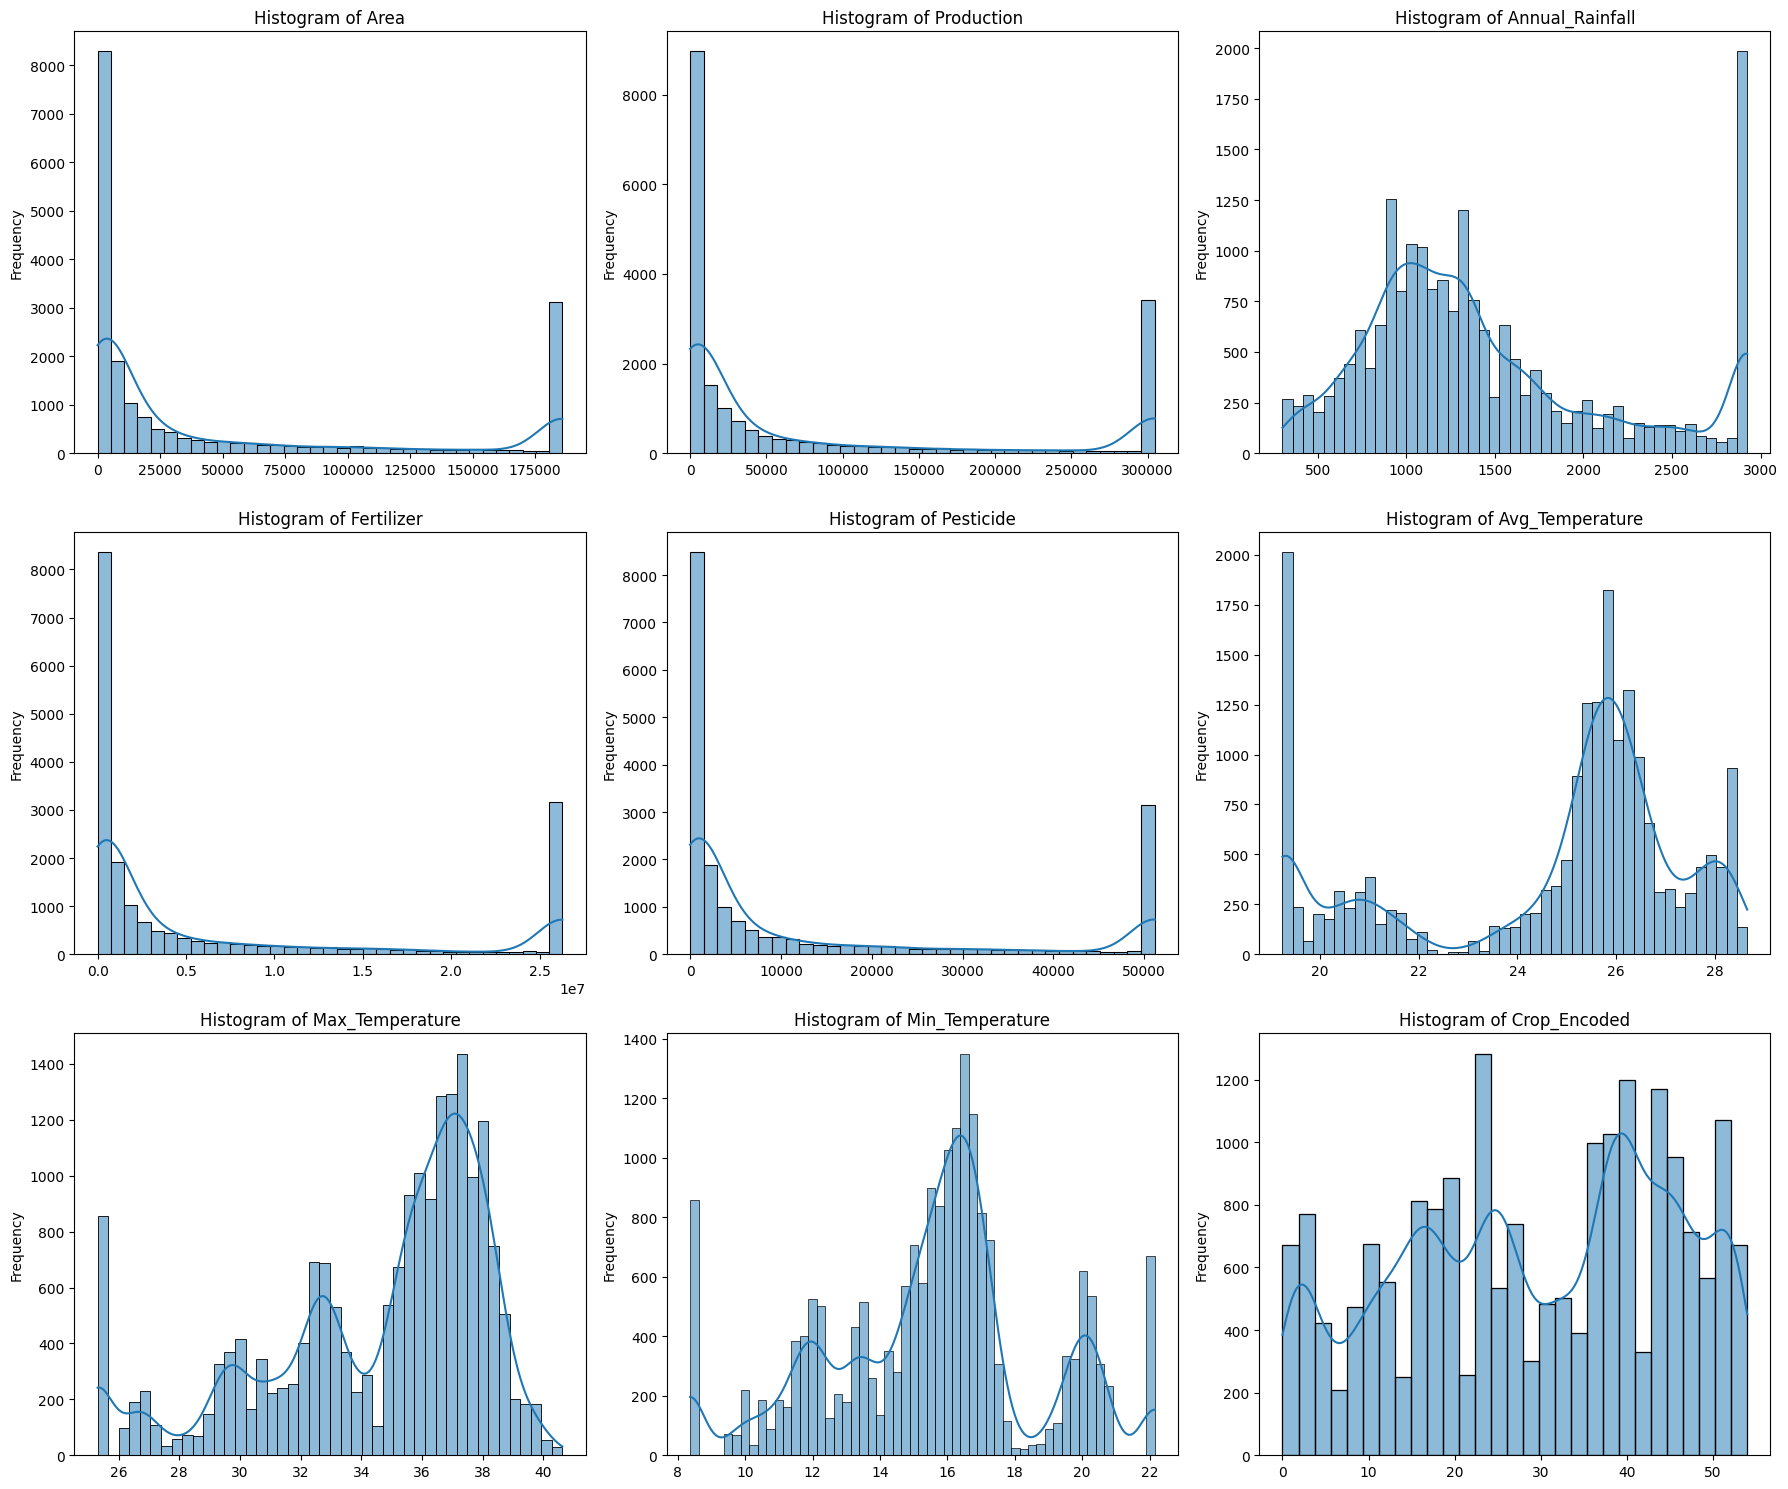

Histogram selesai dibuat.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memastikan `numerical_cols` terdefinisi dan diperbarui setelah penghapusan kolom
numerical_cols_current = df.select_dtypes(include=np.number).columns.tolist()

print("Membuat histogram untuk setiap kolom numerik...")

# Jumlah kolom yang akan diplot per baris
n_cols_per_row = 3
n_rows = (len(numerical_cols_current) + n_cols_per_row - 1) // n_cols_per_row

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(18, n_rows * 5))
axes = axes.flatten() # Untuk memudahkan iterasi jika ada satu baris

for i, col in enumerate(numerical_cols_current):
    sns.histplot(df[col], kde=True, ax=axes[i]) # kde=True untuk menampilkan kurva kepadatan
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('') # Menghilangkan label x agar tidak tumpang tindih
    axes[i].set_ylabel('Frequency')

# Menghilangkan subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
print("Histogram selesai dibuat.")

Membuat heatmap korelasi untuk kolom-kolom numerik...


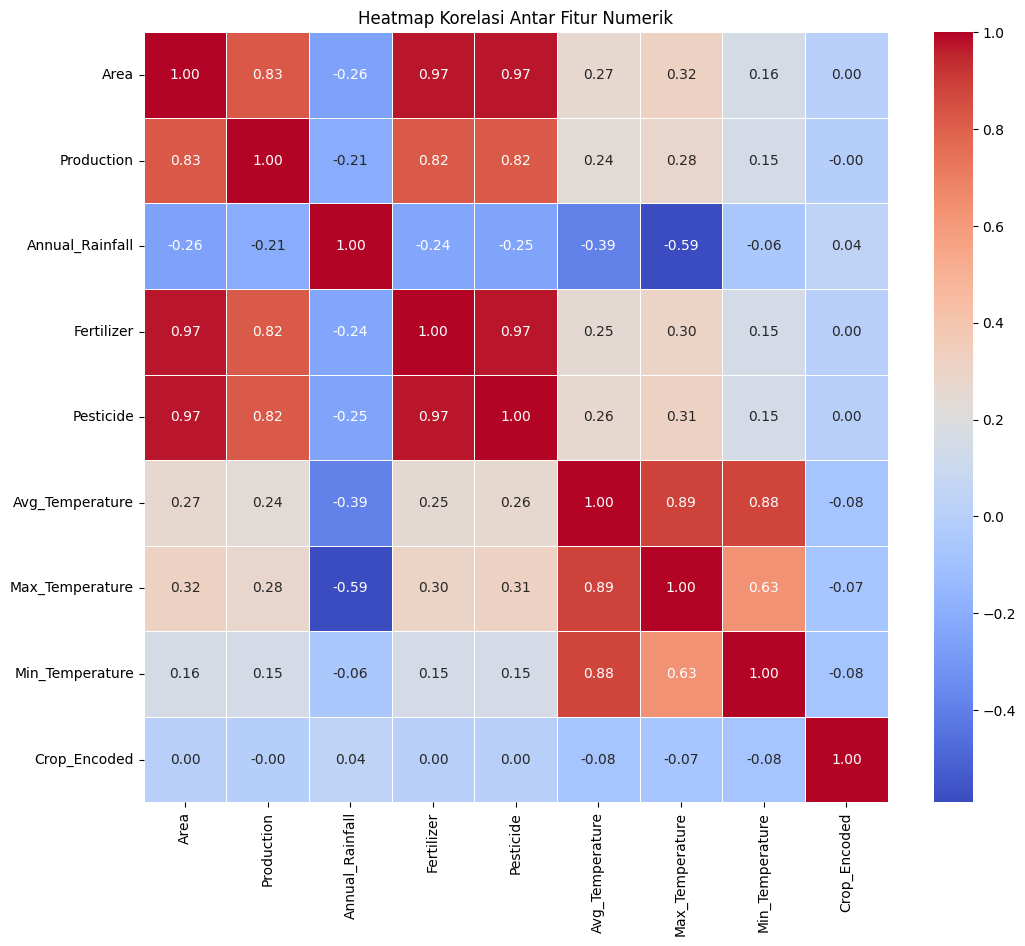

Heatmap korelasi selesai dibuat.


In [14]:
print("Membuat heatmap korelasi untuk kolom-kolom numerik...")

# Memilih kolom numerik yang tersisa
numerical_cols_for_corr = df.select_dtypes(include=np.number).columns.tolist()

# Menghitung matriks korelasi
correlation_matrix = df[numerical_cols_for_corr].corr()

# Membuat heatmap
plt.figure(figsize=(12, 10)) # Atur ukuran figure agar heatmap terlihat jelas
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

print("Heatmap korelasi selesai dibuat.")

In [15]:
print("Korelasi Antar Fitur dengan 'Production':")

# Memilih kolom numerik yang tersisa (termasuk kolom yang sudah di-encode)
numerical_cols_final = df.select_dtypes(include=np.number).columns.tolist()

# Menghitung matriks korelasi
correlation_matrix_final = df[numerical_cols_final].corr()

# Menampilkan korelasi dengan kolom 'Production'
display(correlation_matrix_final[['Production']].sort_values(by='Production', ascending=False))

Korelasi Antar Fitur dengan 'Production':


,Production
Production,1.000000
Area,0.825385
Pesticide,0.818245
Fertilizer,0.816994
Max_Temperature,0.275702
Avg_Temperature,0.237652
Min_Temperature,0.152380
Crop_Encoded,-0.003402
Annual_Rainfall,-0.205404


### Data Splitting

In [16]:
print("Memisahkan fitur (X) dan target (y)...")

y = df['Production']  # Variabel target
X = df.drop('Production', axis=1)  # Fitur-fitur independen

print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)

Memisahkan fitur (X) dan target (y)...
Bentuk X: (19689, 13)
Bentuk y: (19689,)


In [17]:
from sklearn.model_selection import train_test_split

print("Melakukan split data 90:10 (train:test)...")
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(X, y, test_size=0.10, random_state=42)
print(f"Split 90:10: X_train: {X_train_90.shape}, X_test: {X_test_10.shape}")

print("\nMelakukan split data 80:20 (train:test)...")
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Split 80:20: X_train: {X_train_80.shape}, X_test: {X_test_20.shape}")

print("\nMelakukan split data 70:30 (train:test)...")
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.30, random_state=42)
print(f"Split 70:30: X_train: {X_train_70.shape}, X_test: {X_test_30.shape}")

Melakukan split data 90:10 (train:test)...
Split 90:10: X_train: (17720, 13), X_test: (1969, 13)

Melakukan split data 80:20 (train:test)...
Split 80:20: X_train: (15751, 13), X_test: (3938, 13)

Melakukan split data 70:30 (train:test)...
Split 70:30: X_train: (13782, 13), X_test: (5907, 13)


### Model Building

In [18]:
results = []

splits_data = [
    (X_train_90, X_test_10, y_train_90, y_test_10, '90:10'),
    (X_train_80, X_test_20, y_train_80, y_test_20, '80:20'),
    (X_train_70, X_test_30, y_train_70, y_test_30, '70:30')
]

models_to_evaluate = [
    ('Decision Tree Regressor', DecisionTreeRegressor(random_state=42)),
    ('Random Forest Regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('XGBoost Regressor', XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1))
]

## Evaluasi model

In [19]:
results = []

for X_train_curr, X_test_curr, y_train_curr, y_test_curr, split_name in splits_data:
    print(f"\nEvaluating models for split: {split_name}")
    for model_name, model in models_to_evaluate:
        print(f"  Training and evaluating {model_name}...")

        # Train the model
        model.fit(X_train_curr, y_train_curr)

        # Make predictions on test set
        y_pred_test = model.predict(X_test_curr)

        # Evaluate the model on test set
        mae_test = mean_absolute_error(y_test_curr, y_pred_test)
        mse_test = mean_squared_error(y_test_curr, y_pred_test)
        rmse_test = np.sqrt(mse_test)
        r2_test = r2_score(y_test_curr, y_pred_test)

        results.append({
            'Split': split_name,
            'Model': model_name,
            'MAE': mae_test,
            'MSE': mse_test,
            'RMSE': rmse_test,
            'R2': r2_test
        })

# Convert results to DataFrame
results_df_all = pd.DataFrame(results)
display(results_df_all)

# Find the best model based on R2 score (test set)
best_model_overall = results_df_all.loc[results_df_all['R2'].idxmax()]

print("\nModel Terbaik Secara Keseluruhan (berdasarkan R2 Score):")
display(best_model_overall)



Evaluating models for split: 90:10
  Training and evaluating Decision Tree Regressor...
  Training and evaluating Random Forest Regressor...
  Training and evaluating XGBoost Regressor...

Evaluating models for split: 80:20
  Training and evaluating Decision Tree Regressor...
  Training and evaluating Random Forest Regressor...
  Training and evaluating XGBoost Regressor...

Evaluating models for split: 70:30
  Training and evaluating Decision Tree Regressor...
  Training and evaluating Random Forest Regressor...
  Training and evaluating XGBoost Regressor...


,Split,Model,MAE,MSE,RMSE,R2
0,90:10,Decision Tree Regressor,14348.937786,1.714948e+09,41411.935072,0.873993
1,90:10,Random Forest Regressor,12836.354708,8.983922e+08,29973.190955,0.933990
2,90:10,XGBoost Regressor,12411.845525,6.338523e+08,25176.423856,0.953427
3,80:20,Decision Tree Regressor,14492.331640,1.695242e+09,41173.311641,0.872438
4,80:20,Random Forest Regressor,13428.113201,9.328544e+08,30542.664902,0.929805
5,80:20,XGBoost Regressor,12858.766947,6.732865e+08,25947.764768,0.949337
6,70:30,Decision Tree Regressor,15259.555697,1.740785e+09,41722.720822,0.869793
7,70:30,Random Forest Regressor,13998.319684,9.888639e+08,31446.206889,0.926035
8,70:30,XGBoost Regressor,13212.402136,6.824083e+08,26122.945765,0.948957



Model Terbaik Secara Keseluruhan (berdasarkan R2 Score):


,2
Split,90:10
Model,XGBoost Regressor
MAE,12411.845525
MSE,633852318.157459
RMSE,25176.423856
R2,0.953427


Memvisualisasikan R2 Score untuk setiap model dan split data...


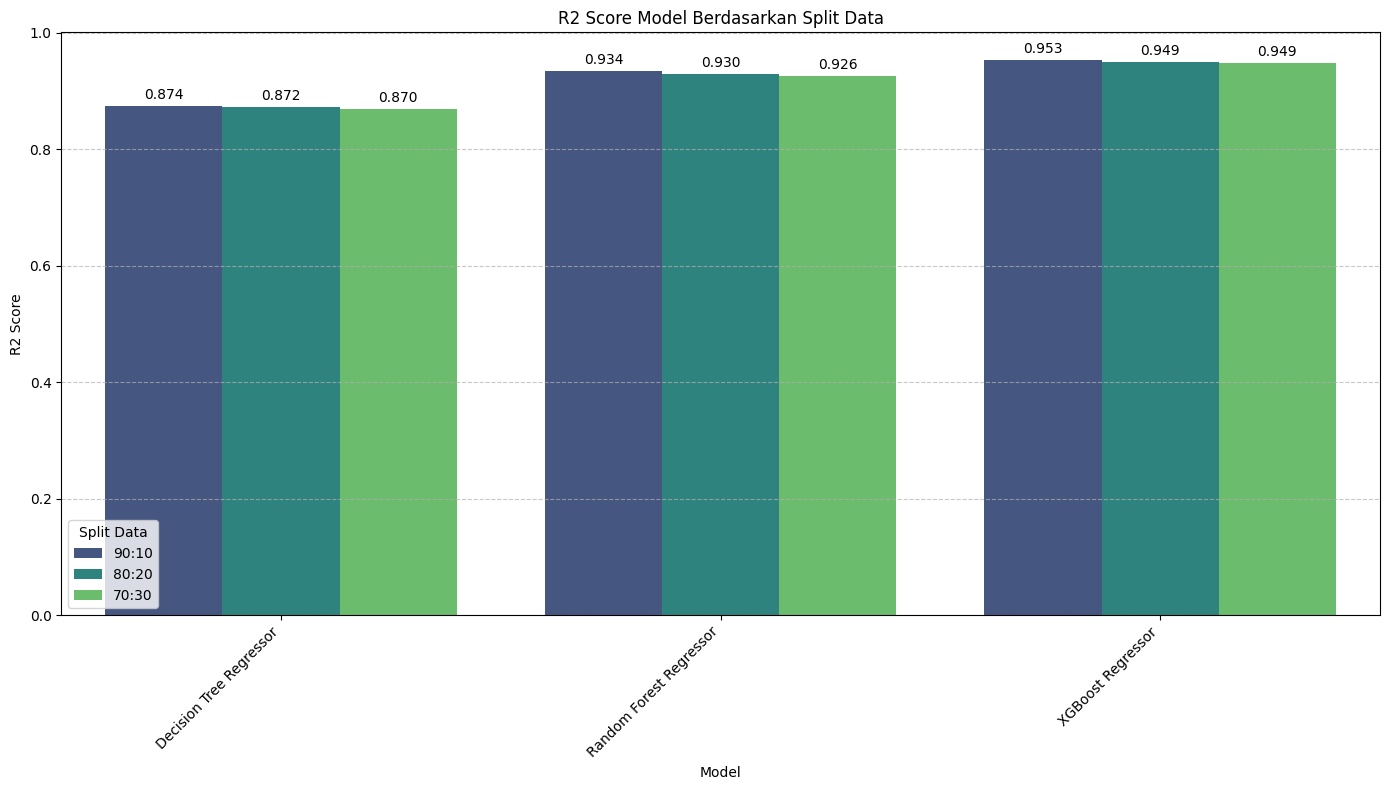

Visualisasi R2 Score selesai.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame operations

print("Memvisualisasikan R2 Score untuk setiap model dan split data...")

# Check if results_df_all is defined. If not, it means the evaluation cell was not run.
# To prevent NameError, we'll create an empty DataFrame as a fallback.
# User should ensure the evaluation cell (which generates results_df_all) is executed.
if 'results_df_all' not in globals():
    print("Peringatan: 'results_df_all' tidak ditemukan. Pastikan sel evaluasi model telah dijalankan.")
    results_df_all = pd.DataFrame(columns=['Model', 'R2', 'Split']) # Create an empty DataFrame to avoid NameError

plt.figure(figsize=(14, 8))
barplot = sns.barplot(x='Model', y='R2', hue='Split', data=results_df_all, palette='viridis')
plt.title('R2 Score Model Berdasarkan Split Data')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Split Data')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add numerical labels on top of each bar
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.3f', padding=3) # Format to 3 decimal places

plt.tight_layout()
plt.show()

print("Visualisasi R2 Score selesai.")

### Hyperparameter Tuning untuk Model Terbaik (XGBoost Regressor)

In [21]:
print("Memulai hyperparameter tuning untuk XGBoost Regressor...")

# Definisikan parameter grid untuk RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Gunakan RandomizedSearchCV pada split data terbaik (90:10)
# n_iter_search adalah jumlah kombinasi parameter yang akan dicoba
random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=50,
                                   scoring='r2', cv=3, verbose=1, random_state=42, n_jobs=-1)

random_search.fit(X_train_90, y_train_90)

print("Hyperparameter tuning selesai.")
print("\nParameter Terbaik:")
display(random_search.best_params_)

# Evaluasi model terbaik dari RandomizedSearchCV
best_xgb_model = random_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test_10)

mae_tuned = mean_absolute_error(y_test_10, y_pred_tuned)
mse_tuned = mean_squared_error(y_test_10, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test_10, y_pred_tuned)

print("\nKinerja Model XGBoost yang Telah di-Tuning (split 90:10):")
tuned_results = pd.DataFrame([{
    'Model': 'XGBoost Regressor Tuned',
    'MAE': mae_tuned,
    'MSE': mse_tuned,
    'RMSE': rmse_tuned,
    'R2': r2_tuned
}])
display(tuned_results)

# Bandingkan dengan kinerja model XGBoost sebelumnya (tanpa tuning)
original_xgb_performance = results_df_all[
    (results_df_all['Split'] == '90:10') &
    (results_df_all['Model'] == 'XGBoost Regressor')
]
print("\nKinerja Model XGBoost Awal (split 90:10):")
display(original_xgb_performance)


Memulai hyperparameter tuning untuk XGBoost Regressor...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Hyperparameter tuning selesai.

Parameter Terbaik:


{'subsample': 1.0,
 'n_estimators': 500,
 'max_depth': 6,
 'learning_rate': 0.1,
 'gamma': 0,
 'colsample_bytree': 0.9}


Kinerja Model XGBoost yang Telah di-Tuning (split 90:10):


,Model,MAE,MSE,RMSE,R2
0,XGBoost Regressor Tuned,11477.918158,5.736156e+08,23950.273551,0.957853



Kinerja Model XGBoost Awal (split 90:10):


,Split,Model,MAE,MSE,RMSE,R2
2,90:10,XGBoost Regressor,12411.845525,6.338523e+08,25176.423856,0.953427


## Model Comparison

Memvisualisasikan perbandingan R2 Score antara model XGBoost sebelum dan sesudah tuning...


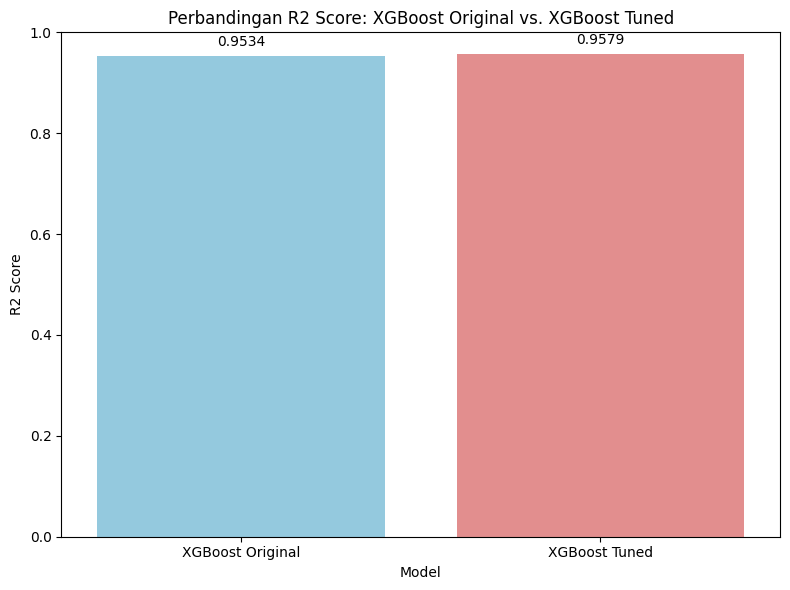

Visualisasi perbandingan R2 Score selesai.


In [22]:
print("Memvisualisasikan perbandingan R2 Score antara model XGBoost sebelum dan sesudah tuning...")

# Gabungkan hasil dari model awal dan model yang sudah di-tuning
comparison_df = pd.concat([original_xgb_performance[['Model', 'R2']], tuned_results[['Model', 'R2']]])
comparison_df['Model'] = comparison_df['Model'].replace({
    'XGBoost Regressor': 'XGBoost Original',
    'XGBoost Regressor Tuned': 'XGBoost Tuned'
})

plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Model', y='R2', hue='Model', data=comparison_df, palette=['skyblue', 'lightcoral'], legend=False)
plt.title('Perbandingan R2 Score: XGBoost Original vs. XGBoost Tuned')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for R2 scores

# Tambahkan label numerik di atas setiap bar
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.4f', padding=5)

plt.tight_layout()
plt.show()

print("Visualisasi perbandingan R2 Score selesai.")

Memvisualisasikan Feature Importance dari model XGBoost terbaik...


/tmp/ipykernel_4674/412395600.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


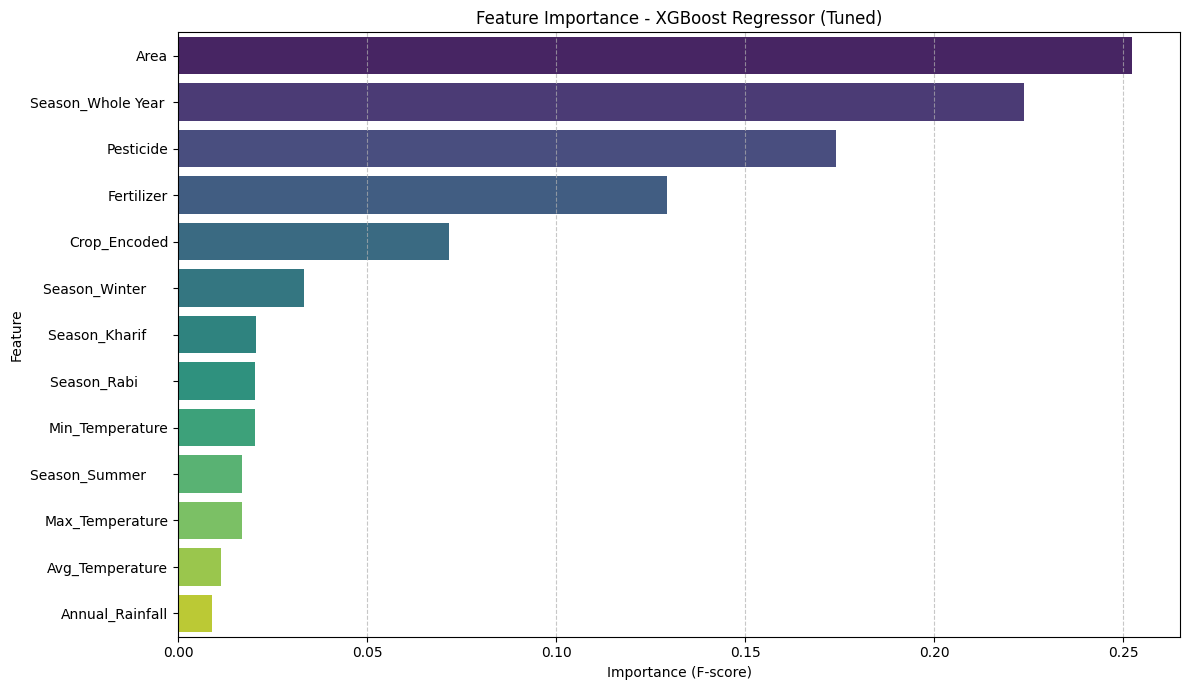

Visualisasi Feature Importance selesai.


In [23]:
print("Memvisualisasikan Feature Importance dari model XGBoost terbaik...")

# Pastikan best_xgb_model sudah tersedia
if 'best_xgb_model' in locals():
    # Dapatkan feature importances
    feature_importances = best_xgb_model.feature_importances_

    # Dapatkan nama fitur dari X_train_90 (karena ini split yang digunakan untuk tuning)
    feature_names = X_train_90.columns

    # Buat DataFrame untuk mempermudah visualisasi
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

    # Urutkan berdasarkan importance
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Buat bar plot
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importance - XGBoost Regressor (Tuned)')
    plt.xlabel('Importance (F-score)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("Visualisasi Feature Importance selesai.")
else:
    print("ERROR: Model terbaik (best_xgb_model) tidak ditemukan. Pastikan sel 'Hyperparameter Tuning' telah dijalankan.")

In [24]:
print("Hasil Evaluasi Model untuk Setiap Split Data (Test Set):")
display(results_df_all)

print("Visualisasi R2 Score selesai.")

Hasil Evaluasi Model untuk Setiap Split Data (Test Set):


,Split,Model,MAE,MSE,RMSE,R2
0,90:10,Decision Tree Regressor,14348.937786,1.714948e+09,41411.935072,0.873993
1,90:10,Random Forest Regressor,12836.354708,8.983922e+08,29973.190955,0.933990
2,90:10,XGBoost Regressor,12411.845525,6.338523e+08,25176.423856,0.953427
3,80:20,Decision Tree Regressor,14492.331640,1.695242e+09,41173.311641,0.872438
4,80:20,Random Forest Regressor,13428.113201,9.328544e+08,30542.664902,0.929805
5,80:20,XGBoost Regressor,12858.766947,6.732865e+08,25947.764768,0.949337
6,70:30,Decision Tree Regressor,15259.555697,1.740785e+09,41722.720822,0.869793
7,70:30,Random Forest Regressor,13998.319684,9.888639e+08,31446.206889,0.926035
8,70:30,XGBoost Regressor,13212.402136,6.824083e+08,26122.945765,0.948957


Visualisasi R2 Score selesai.


### Inferensi dengan Data Baru

In [25]:
#@title Input Data Baru { form-width: "600px" }

# Input fields for new data using Colab forms
new_crop = 'Arhar/Tur' #@param ['Arecanut', 'Arhar/Tur', 'Bajra', 'Banana', 'Black pepper', 'Cardamom', 'Cashewnut', 'Castor seed', 'Coconut', 'Coffee', 'Cotton(lint)', 'Dry chillies', 'Dry ginger', 'Garlic', 'Gram', 'Groundnut', 'Jowar', 'Linseed', 'Maize', 'Mesta', 'Moong', 'Niger seed', 'Onion', 'Other Kharif pulses', 'Other Rabi pulses', 'Other cereals', 'Other fibres', 'Other oilseeds', 'Paddy', 'Potato', 'Pulses', 'Ragi', 'Rapeseed & Mustard', 'Rice', 'Safflower', 'Sugarcane', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric', 'Urad', 'Wheat', 'Small millets']
new_season = 'Kharif' #@param ['Kharif', 'Rabi', 'Summer     ', 'Autumn     ', 'Winter     ', 'Whole Year     ']
new_area = 6637.0 #@param {type:"number"}
new_annual_rainfall = 2051.4 #@param {type:"number"}
new_fertilizer = 631643.29 #@param {type:"number"}
new_pesticide = 2057.47 #@param {type:"number"}
new_avg_temperature = 23.692 #@param {type:"number"}
new_max_temperature = 33.435 #@param {type:"number"}
new_min_temperature = 14.779 #@param {type:"number"}

# Construct new_data_input dictionary from form values
new_data_input_from_form = {
    'Crop': [new_crop],
    'Season': [new_season],
    'Area': [new_area],
    'Annual_Rainfall': [new_annual_rainfall],
    'Fertilizer': [new_fertilizer],
    'Pesticide': [new_pesticide],
    'Avg_Temperature': [new_avg_temperature],
    'Max_Temperature': [new_max_temperature],
    'Min_Temperature': [new_min_temperature]
    # Crop_Year and State are not needed as per the final MODEL_EXPECTED_FEATURES
}

new_df_form = pd.DataFrame(new_data_input_from_form)

print("Input data dari formulir:")
display(new_df_form)




# --- PREDICTION LOGIC START ---

print("\n--- Memproses data input dan membuat prediksi ---")

# Use new_df_form generated from the @param cell
new_df = new_df_form.copy()

# --- Preprocessing Data Baru (sesuai dengan proses pelatihan) ---

# 1. Cleaning dan konversi numerik (seperti di cell sUXqMf_ZJ_1P)
NUM_COLS_INFERENCE = ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide'] # Columns that might need cleaning based on initial data types

def clean_numeric_inference(value):
    if pd.isna(value): return np.nan
    s = str(value).strip()
    if s.count('.') > 1:
        s = s.replace('.', '')
    s = s.replace(',', '.')
    return s

for col in NUM_COLS_INFERENCE:
    if col in new_df.columns:
        new_df[col] = new_df[col].apply(clean_numeric_inference)
        new_df[col] = pd.to_numeric(new_df[col], errors='coerce')
        # Fill missing with median from original training data, assuming 'df' is still the processed training df
        new_df[col] = new_df[col].fillna(df[col].median())

# 2. Label Encoding untuk 'Crop'
# To ensure the LabelEncoder recognizes all possible input crops, re-fit it with the full list of options.
# This prevents 'unseen labels' errors if 'le' from a previous cell was not fitted on a comprehensive list.
all_crop_options = ['Arecanut', 'Arhar/Tur', 'Bajra', 'Banana', 'Black pepper', 'Cardamom', 'Cashewnut', 'Castor seed', 'Coconut', 'Coffee', 'Cotton(lint)', 'Dry chillies', 'Dry ginger', 'Garlic', 'Gram', 'Groundnut', 'Jowar', 'Linseed', 'Maize', 'Mesta', 'Moong', 'Niger seed', 'Onion', 'Other Kharif pulses', 'Other Rabi pulses', 'Other cereals', 'Other fibres', 'Other oilseeds', 'Paddy', 'Potato', 'Pulses', 'Ragi', 'Rapeseed & Mustard', 'Rice', 'Safflower', 'Sugarcane', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric', 'Urad', 'Wheat', 'Small millets']
le = LabelEncoder() # Re-initialize le for robust inference
le.fit(all_crop_options) # Fit with all possible crops from the dropdown

# --- Final alignment of new data to model's expected features ---

# The list of features the model expects (derived from the traceback's 'feature_names_in_'):
MODEL_EXPECTED_FEATURES = [
    'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature',
    'Max_Temperature', 'Min_Temperature', 'Crop_Encoded',
    'Season_Kharif     ', 'Season_Rabi       ', 'Season_Summer     ',
    'Season_Whole Year ', 'Season_Winter     '
]

# Create an empty DataFrame with the model's expected features, initialized to 0
final_inference_df = pd.DataFrame(0, index=new_df.index, columns=MODEL_EXPECTED_FEATURES)

# Populate numerical features from new_df (already cleaned)
for col in ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']:
    if col in new_df.columns and col in final_inference_df.columns:
        final_inference_df[col] = new_df[col]

# Populate Crop_Encoded using the correct 'le'
if 'Crop_Encoded' in final_inference_df.columns:
    final_inference_df['Crop_Encoded'] = le.transform(new_df['Crop'])

# Populate Season One-Hot Encoded features
new_season_category = new_df['Season'].iloc[0].strip() # Get the season from input and strip spaces

for season_col_name_in_model in [col for col in MODEL_EXPECTED_FEATURES if 'Season_' in col]:
    # Check if the stripped season name from input matches the stripped season name in the model's OHE column
    if season_col_name_in_model.strip() == f'Season_{new_season_category}':
        final_inference_df[season_col_name_in_model] = 1
        break # Assuming only one season per data point

new_data_for_prediction = final_inference_df

print("Data baru setelah preprocessing (digunakan untuk prediksi):")
display(new_data_for_prediction)

# --- Prediksi dengan Model Terbaik ---

# Pastikan model terbaik sudah tersedia dari cell sebelumnya
if 'best_xgb_model' in locals():
    prediction = best_xgb_model.predict(new_data_for_prediction)
    # Post-processing: Cap negative predictions at zero as production cannot be negative
    prediction[prediction < 0] = 0
    print(f"\nPrediksi Production untuk data baru: {prediction[0]:,.2f}")
else:
    print("ERROR: Model terbaik (best_xgb_model) tidak ditemukan. Pastikan cell 'Hyperparameter Tuning' telah dijalankan.")
# --- PREDICTION LOGIC END ---

Input data dari formulir:


,Crop,Season,Area,Annual_Rainfall,Fertilizer,Pesticide,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arhar/Tur,Kharif,6637.0,2051.4,631643.29,2057.47,23.692,33.435,14.779



--- Memproses data input dan membuat prediksi ---
Data baru setelah preprocessing (digunakan untuk prediksi):


,Area,Annual_Rainfall,Fertilizer,Pesticide,Avg_Temperature,Max_Temperature,Min_Temperature,Crop_Encoded,Season_Kharif,Season_Rabi,Season_Summer,Season_Whole Year,Season_Winter
0,6637.0,2051.4,631643.29,2057.47,23.692,33.435,14.779,1,1,0,0,0,0



Prediksi Production untuk data baru: 5,313.75


In [26]:
import joblib

print("Menyimpan model ke file .pkl...")

# Pastikan model terbaik tersedia
if 'best_xgb_model' in locals():

    # Simpan semua komponen penting dalam satu dictionary
    model_package = {
        'model': best_xgb_model,
        'label_encoder': le,
        'feature_names': MODEL_EXPECTED_FEATURES
    }

    # Simpan ke file pkl
    joblib.dump(model_package, 'model_produksi_tanaman.pkl')

    print("Model berhasil disimpan sebagai 'model_produksi_tanaman.pkl'")

else:
    print("ERROR: Model terbaik belum tersedia. Jalankan bagian training terlebih dahulu.")

Menyimpan model ke file .pkl...
Model berhasil disimpan sebagai 'model_produksi_tanaman.pkl'
